# Lab U1: Vectors, Similarity, Attention, and Matrix Actions

**Unit:** Unit 1, Vectors, Matrices, and Linear Maps  
**Textbook sections:** Review of vector geometry and applications; Matrices; Matrix-vector product; Linear and affine maps; Matrix multiplication and linear map composition; Applications and computation recap  
**Core path:** vector applications, document similarity, token attention, matrix-vector products, geometric matrix actions, composition, and affine maps  
**Submission note:** No code submission is expected; this lab supports in-class interpretation questions and guided review.

This lab is about reading short NumPy snippets as linear algebra. The goal is not to write long programs. The goal is to predict small outputs, identify shapes, translate code into mathematics, and explain what the computation means.

Part 0 is a warm-up. Parts 1-7 are core unless marked extension. The final part contains review code-reading checks.


### Computational tools used in this lab

Before starting, review these parts of **Appendix B, NumPy and SymPy Quick Reference for the Labs**:

- Appendix B.2: NumPy arrays, vectors, matrices, and shapes
- Appendix B.3: Indexing and slicing
- Appendix B.4: Elementwise arithmetic versus linear algebra
- Appendix B.5: Dot products, norms, distances, and cosine similarity
- Appendix B.6: Sorting and rankings
- Appendix B.7: Reductions, axes, and row-wise computations
- Appendix B.8: Constructing common arrays and design matrices
- Appendix B.9: Numerical checks and roundoff

The goal is to interpret the mathematical computation, not to memorize every command.

## Part 0. NumPy warm-up: arrays, shapes, and `@`

**Math reminder.** A vector is an ordered list of numbers. A matrix is a rectangular array. In NumPy, `A @ u` means matrix-vector multiplication when `A` is a matrix and `u` is a compatible vector.

**Predict before running.** Is `u` a scalar, vector, or matrix? What is the shape of `A`? Is `A @ u` a dot product, matrix-vector product, or entry-by-entry product?

**Run and compare.**

In [1]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

u = np.array([3.0, 4.0])
A = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
])

u.shape, A.shape, A @ u

((2,), (2, 2), array([11., 25.]))

**Interpretation check.** `u` is a vector with shape `(2,)`; `A` is a `2 x 2` matrix; `A @ u` is a matrix-vector product.

**Common mistake.** `@` is not the same as entry-by-entry multiplication. It uses rows of `A` and the vector `u` to produce a new vector.

## Part 1. Vectors, dot products, norms, distances, and cosine similarity

**Math reminder.** Dot products measure alignment. Norms measure length. Distance is the norm of a difference. Cosine similarity normalizes the dot product so that direction matters more than raw length.

**Predict before running.** For `u = (3,4)` and `v = (4,3)`, should the cosine similarity be positive, negative, or zero? Should it be close to 1?

In [2]:
u = np.array([3.0, 4.0])
v = np.array([4.0, 3.0])

dot = u @ v
norm_u = np.linalg.norm(u)
distance = np.linalg.norm(u - v)
cosine = dot / (np.linalg.norm(u) * np.linalg.norm(v))

dot, norm_u, distance, cosine

(24.0, 5.0, 1.4142135623730951, 0.96)

**Run and compare.** The output is approximately `(24.0, 5.0, 1.414, 0.96)`.

**Interpretation check.** The dot product is positive and the cosine similarity is close to 1, so the two vectors point in similar directions.

**Review check.** Which quantity changes if `u` is doubled: dot product, norm, distance, cosine similarity? Which of these is designed to ignore overall scale?

## Part 2. Word-count vectors and retrieval

**Math reminder.** A document vector records features of a document. Here the coordinates count selected terms. Cosine similarity ranks documents by direction after normalization.

**Code snapshot.** Rows are documents; columns are the selected terms `linear`, `matrix`, and `data`.

**Predict before running.** The query represents the phrase `linear data`. Which document should have the largest cosine similarity?


In [3]:
doc_names = np.array(["D1", "D2", "D3"])

X = np.array([
    [2, 0, 2],
    [1, 1, 0],
    [0, 2, 0],
], dtype=float)

q = np.array([1, 0, 1], dtype=float)

scores = (X @ q) / (np.linalg.norm(X, axis=1) * np.linalg.norm(q))
ranking = doc_names[np.argsort(scores)[::-1]]

scores, ranking


(array([1. , 0.5, 0. ]), array(['D1', 'D2', 'D3'], dtype='<U2'))

**Run and compare.** The cosine scores are `[1.0, 0.5, 0.0]`, so the ranking is `D1`, `D2`, `D3`.

**Interpretation check.** Cosine similarity compares direction. `D1` has score 1 because it is a scalar multiple of the query.

**Common mistake.** A document can share one query word without pointing in the same direction after normalization.


## Part 3. Token attention preview

**Math reminder.** In this toy attention preview, dot products produce relevance scores, positive scores are normalized into weights, and the weights form a weighted average of value vectors.

**Predict before running.** Why should `K @ q` produce three scores? Which token row of `K` should have the largest score?


In [4]:
tokens = np.array(["small", "red", "bird"])

q = np.array([1.0, 1.0])

K = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

V = np.array([
    [4.0, 0.0],
    [0.0, 4.0],
    [4.0, 4.0],
])

s = K @ q
alpha = s / s.sum()
out = alpha @ V

s, alpha, out


(array([1., 1., 2.]), array([0.25, 0.25, 0.5 ]), array([3., 3.]))

In [5]:
q.shape, K.shape, V.shape, s.shape, alpha.shape, out.shape, alpha.sum()

((2,), (3, 2), (3, 2), (3,), (3,), (2,), 1.0)

**Run and compare.** `s = [1, 1, 2]`, `alpha = [0.25, 0.25, 0.5]`, and `out = [3, 3]`.

**Interpretation check.** `K @ q` computes one dot-product score for each key row. `alpha @ V` is a weighted average of rows of `V`.

**Common mistake.** This is an attention-style preview, not full attention. Full attention uses additional normalization choices; this toy example normalizes positive scores by their sum.


## Part 4. Matrix-vector multiplication: rows measure, columns contribute

**Math reminder.** The product `A @ x` has two complementary readings. In the row view, each output entry is a row dot product. In the column view, `x` gives coefficients in a linear combination of the columns of `A`.

**Predict before running.** What is the shape of `A @ x`?

In [6]:
A = np.array([
    [-1.0, 4.0, -5.0],
    [ 3.0, 1.0, -2.0],
])
x = np.array([2.0, -3.0, 4.0])

row_view = np.array([A[0] @ x, A[1] @ x])
column_view = x[0] * A[:, 0] + x[1] * A[:, 1] + x[2] * A[:, 2]

A @ x, row_view, column_view

(array([-34.,  -5.]), array([-34.,  -5.]), array([-34.,  -5.]))

**Interpretation check.** The row view computes `(-1,4,-5) dot (2,-3,4)` and `(3,1,-2) dot (2,-3,4)`. The column view computes `2*a1 - 3*a2 + 4*a3`.

**Common mistake.** Rows and columns are both involved, but they answer different questions: rows measure input patterns; columns contribute output directions.

## Part 5. Geometric matrix actions and the unit-square visualization

**Math reminder.** Put the vertices of a shape in the columns of a matrix `X_square`. Then `A_shear @ X_square` applies the same matrix to every vertex.

**Predict before running.** What happens to the top edge of the unit square under `A_shear(x,y) = (x + y, y)`?


In [7]:
X_square = np.array([
    [0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 1.0, 0.0],
])

A_shear = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
])

Y_square = A_shear @ X_square
Y_square


array([[0., 1., 2., 1., 0.],
       [0., 0., 1., 1., 0.]])

**Run and compare.** The columns of `X_square` are original vertices. The columns of `Y_square` are transformed vertices. The bottom edge stays fixed and the top edge shifts right by `1`.

**Convention warning.** In this geometric example, inputs are columns. In the document example, documents were rows. Always check what rows and columns represent before interpreting a product.


## Forward look: from square to square grid

In this lab, a matrix acts on many points at once by storing the points as columns of a matrix \(X\) and computing

\[
Y=AX.
\]

For a \(2\times 2\) matrix, the images of the two coordinate directions determine the whole grid.

In Unit 3, the same columns-of-points convention is used for rules that are not matrix maps. Then the four corners of a square may not be enough. A grid of points gives more information.

### Check yourself

1. In \(Y=AX\), what do the columns of \(X\) represent?
2. What do the columns of \(Y\) represent?
3. Why is one matrix enough to move every point in the Unit 1 square test?
4. Why might a grid of many points be more informative for a rule that is not a matrix map?

### Transformation gallery

**Predict before running.** First try replacing `A_shear` by one of these matrices, then predict the transformed square before plotting. The next code cell runs the full gallery one transformation at a time.

- Horizontal stretch: `[[2, 0], [0, 1]]`
- Projection onto the y-axis: `[[0, 0], [0, 1]]`
- Reflection across the y-axis: `[[-1, 0], [0, 1]]`
- Horizontal shear: `[[1, 1], [0, 1]]`
- Quarter-turn rotation: `[[0, -1], [1, 0]]`
- Projection onto the x-axis: `[[1, 0], [0, 0]]`


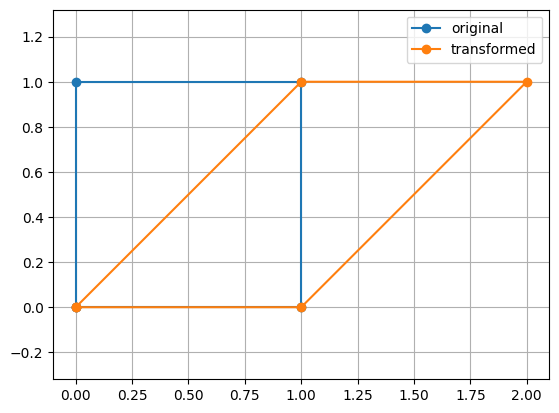

In [8]:
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    print("Optional plotting skipped:", exc)
else:
    plt.plot(X_square[0], X_square[1], "o-", label="original")
    plt.plot(Y_square[0], Y_square[1], "o-", label="transformed")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()


horizontal stretch
A =
[[2. 0.]
 [0. 1.]]
transformed vertices =
[[0. 2. 2. 0. 0.]
 [0. 0. 1. 1. 0.]]


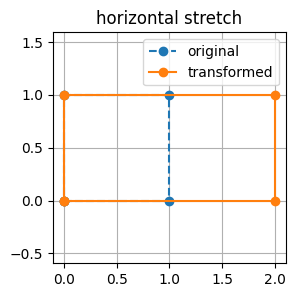


projection onto the y-axis
A =
[[0. 0.]
 [0. 1.]]
transformed vertices =
[[0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]


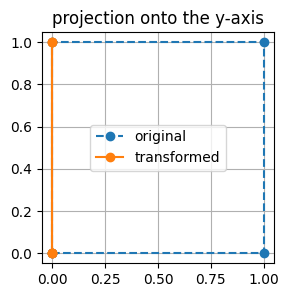


reflection across the y-axis
A =
[[-1.  0.]
 [ 0.  1.]]
transformed vertices =
[[ 0. -1. -1.  0.  0.]
 [ 0.  0.  1.  1.  0.]]


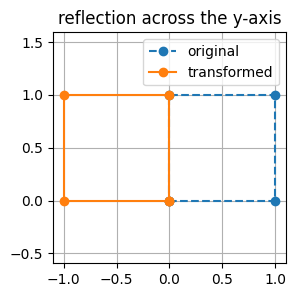


horizontal shear
A =
[[1. 1.]
 [0. 1.]]
transformed vertices =
[[0. 1. 2. 1. 0.]
 [0. 0. 1. 1. 0.]]


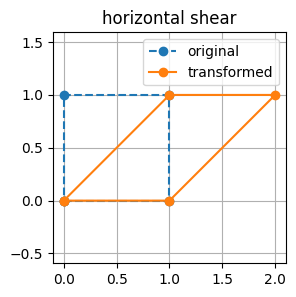


quarter-turn rotation
A =
[[ 0. -1.]
 [ 1.  0.]]
transformed vertices =
[[ 0.  0. -1. -1.  0.]
 [ 0.  1.  1.  0.  0.]]


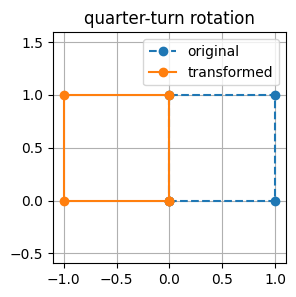


projection onto the x-axis
A =
[[1. 0.]
 [0. 0.]]
transformed vertices =
[[0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0.]]


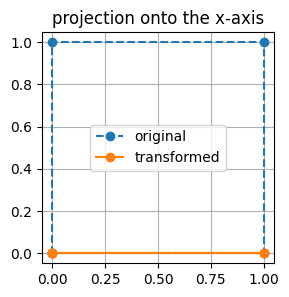

In [9]:
# Run a small gallery of geometric matrix actions.
transformations = [
    ("horizontal stretch", np.array([[2.0, 0.0], [0.0, 1.0]])),
    ("projection onto the y-axis", np.array([[0.0, 0.0], [0.0, 1.0]])),
    ("reflection across the y-axis", np.array([[-1.0, 0.0], [0.0, 1.0]])),
    ("horizontal shear", np.array([[1.0, 1.0], [0.0, 1.0]])),
    ("quarter-turn rotation", np.array([[0.0, -1.0], [1.0, 0.0]])),
    ("projection onto the x-axis", np.array([[1.0, 0.0], [0.0, 0.0]])),
]

try:
    import matplotlib.pyplot as plt
    plot_gallery = True
except Exception as exc:
    print("Optional plotting skipped:", exc)
    plot_gallery = False

for name, A in transformations:
    Y = A @ X_square
    print(f"\n{name}")
    print("A =")
    print(A)
    print("transformed vertices =")
    print(np.round(Y, 3))

    if plot_gallery:
        plt.figure(figsize=(3, 3))
        plt.plot(X_square[0], X_square[1], "o--", label="original")
        plt.plot(Y[0], Y[1], "o-", label="transformed")
        plt.title(name)
        plt.axis("equal")
        plt.grid(True)
        plt.legend()
        plt.show()


## Part 6. Matrix multiplication and linear map composition

**Math reminder.** In `B @ A`, the rightmost matrix acts first: apply `A`, then apply `B`. Matrix multiplication usually depends on order.

**Predict before running.** Which product represents "stretch horizontally, then rotate"? Are the two products equal?

In [10]:
S = np.array([
    [2.0, 0.0],
    [0.0, 1.0],
])

R = np.array([
    [0.0, -1.0],
    [1.0,  0.0],
])

R @ S, S @ R

(array([[ 0., -1.],
        [ 2.,  0.]]),
 array([[ 0., -2.],
        [ 1.,  0.]]))

**Run and compare.** `R @ S` applies `S` first and then `R`. The two products are different, so this is a noncommuting example.

**Common mistake.** Do not read `R @ S` from left to right as actions in time. The rightmost matrix acts first.

### Many-token shape check after matrix multiplication

**Math reminder.** Once matrix multiplication is available, many query-key dot products can be packaged into one matrix `Q @ K.T`.

**Predict before running.** If `X_tokens` has shape `(5,4)` and each weight matrix has shape `(4,3)`, what are the shapes of `Q`, `K_tokens`, `V_tokens`, and `scores`?


In [11]:
X_tokens = np.ones((5, 4))
WQ = np.ones((4, 3))
WK = np.ones((4, 3))
WV = np.ones((4, 3))

Q = X_tokens @ WQ
K_tokens = X_tokens @ WK
V_tokens = X_tokens @ WV
scores_many = Q @ K_tokens.T

Q.shape, K_tokens.shape, V_tokens.shape, scores_many.shape

((5, 3), (5, 3), (5, 3), (5, 5))

**Interpretation check.** `Q`, `K_tokens`, and `V_tokens` all have shape `(5,3)`. The score matrix has shape `(5,5)`. Its `(i,j)` entry is the dot product of query row `i` with key row `j`; it is a relevance score, not yet a final output.

## Part 7. Linear versus affine maps

**Math reminder.** A linear map sends the zero vector to the zero vector. An affine map has the form `x -> W @ x + b`; if `b` is nonzero, the map usually moves the origin and is not linear.

**Predict before running.** What are `W @ zero` and `W @ zero + b`?

In [12]:
W = np.array([
    [1.0, 1.0],
    [0.0, 2.0],
])

b = np.array([3.0, -1.0])
zero = np.array([0.0, 0.0])

def f(x):
    return W @ x + b

W @ zero, f(zero), f(np.array([1.0, 2.0]))

(array([0., 0.]), array([ 3., -1.]), array([6., 3.]))

**Interpretation check.** The linear part sends `zero` to `zero`, but the affine map sends `zero` to `b`. Since `b` is nonzero, `f` is not linear.

**Common mistake.** A formula can contain a matrix and still fail to be linear if there is a nonzero added bias vector.

## Part 8. Review code-reading bank

These are short checks for discussion or self-review. They are meant to be answered without writing long programs.

1. **Shape check.** If `u = np.array([3., 4.])`, what is `u.shape`?
2. **Operation ID.** In `u @ v`, what mathematical operation is being computed when both are vectors?
3. **Predict output.** For `u = (3,4)`, what is `np.linalg.norm(u)`?
4. **Scale check.** If `u` is doubled, does cosine similarity with a fixed nonzero `v` necessarily change?
5. **Distance check.** What does `np.linalg.norm(u - v)` measure?
6. **Document data.** In the document matrix `X`, what does one row represent?
7. **Document data.** In the document matrix `X`, what does one column represent?
8. **Ranking.** What does `np.argsort(scores)[::-1]` do in words?
9. **Cosine similarity.** Why does `D1` have cosine similarity 1 with the query in Part 2?
10. **Attention score.** In `s = K @ q`, why does `s` have one entry per row of `K`?
11. **Attention weight.** Why should the entries of `alpha = s / s.sum()` add to one?
12. **Weighted average.** In `out = alpha @ V`, what do the entries of `alpha` control?
13. **Preview caution.** What part of full attention is simplified in this toy attention preview?
14. **Row view.** In `A @ x`, what does the first row of `A` do?
15. **Column view.** In `A @ x`, what role do the entries of `x` play in the column view?
16. **Geometry.** If columns of `X_square` are vertices, what are columns of `A @ X_square`?
17. **Convention check.** Why is it dangerous to assume rows always represent data objects?
18. **Composition order.** Which matrix acts first in `R @ S @ x`?
19. **Noncommuting products.** Does `R @ S == S @ R` usually hold?
20. **Affine test.** What single input quickly tests whether `x -> W @ x + b` can be linear?
21. **Affine interpretation.** What does the bias vector `b` do geometrically?
22. **Many-token shape.** If `Q` and `K` both have shape `(5,3)`, what is the shape of `Q @ K.T`?
23. **Many-token interpretation.** What does one entry of `Q @ K.T` represent?

### Answer sketches

1. `(2,)`.
2. A dot product.
3. `5.0`.
4. No. Cosine similarity compares direction after normalization.
5. Euclidean distance between the two vectors.
6. One document represented by term counts.
7. One selected term or feature.
8. It returns indices sorted from largest score to smallest score.
9. `D1` is a scalar multiple of the query, so it points in the same direction.
10. Each row of `K` is dotted with `q`.
11. Dividing by the sum normalizes the scores into weights.
12. They say how strongly each row of `V` contributes.
13. It uses sum-normalization of positive scores.
14. It measures the input by a row dot product.
15. They are coefficients in a linear combination of columns.
16. The transformed vertices.
17. Some examples store observations in rows; geometric inputs here are columns.
18. `S` acts first, then `R`.
19. No. Matrix multiplication generally depends on order.
20. The zero vector.
21. It translates or shifts the output.
22. `(5,5)`.
23. The dot product of one query row with one key row.
